# Ex03 — Hour 3: Closed-loop remediation + live trigger

**Goal:** End-to-end detect → enrich → decide → act → verify cycle on a LIVE incident replay.

**Scenarios in scope (Hour 3):** S08 (network partition), S09 (noisy neighbor), S10 (slow-burn forecast).

**What you'll do:**
1. Connect to the live SSE stream from FastAPI
2. As events arrive, score them with anomaly detector
3. Once a confirmed incident is detected, query RCA
4. **Decide**: auto-remediate (if confidence high + safe action exists) OR page human
5. Verify metrics return to baseline after action


In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3, json, importlib.util
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Connect to workshop database
DB = Path.cwd().parent / "workshop.db" if (Path.cwd().parent / "workshop.db").exists() else Path("../workshop.db")
conn = sqlite3.connect(DB)

# Helper to import modules with kebab-case filenames (workshop convention)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m); return m

print(f"DB: {DB} ({DB.stat().st_size//1024} KB)")
sql = "SELECT name FROM sqlite_master WHERE type='table'"
tables = [r[0] for r in conn.execute(sql).fetchall()]

print(f"Tables: {tables}")

DB: D:\AWS\Xbrain\AIOps\w2\workshop-student\workshop.db (2704 KB)
Tables: ['services', 'topology', 'metrics', 'alerts', 'log_patterns', 'sqlite_sequence', 'traces', 'scenarios', 'live_events', 'live_state']


## 1. Start the API server (if not running)

In a separate terminal:
```bash
uv run python stack/api.py
```

Verify it's up:

In [3]:
import urllib.request
try:
    r = json.loads(urllib.request.urlopen("http://localhost:8000/api/health", timeout=2).read())
    print(f"API up: {r}")
except Exception as e:
    print(f"API DOWN — start it first: uv run python stack/api.py\nError: {e}")


API up: {'status': 'ok', 'db': 'D:\\AWS\\Xbrain\\AIOps\\w2\\workshop-student\\workshop.db', 'db_exists': True}


## 2. Trigger S08 live replay (60x speed)

Network partition between datapower ↔ esb. 35min scenario plays in ~35 sec.

In [4]:
import urllib.request
req = urllib.request.Request("http://localhost:8000/api/trigger/S08?speed=60", method="POST")
r = json.loads(urllib.request.urlopen(req).read())
print(json.dumps(r, indent=2))


{
  "status": "started",
  "scenario": "S08",
  "speed": 60
}


## 3. Consume the SSE stream

For ~40 sec, collect events. Print alerts as they arrive.

In [5]:
import urllib.request, time
# Use sseclient-py if available, else manual parse
events_seen = []
start = time.time()
def stream_events(timeout=45):
    r = urllib.request.urlopen("http://localhost:8000/stream", timeout=timeout)
    buf = b""
    while time.time() - start < timeout:
        line = r.readline()
        if not line: break
        if line.startswith(b"data: "):
            try:
                evt = json.loads(line[6:].decode())
                events_seen.append(evt)
                if evt["kind"] == "alert":
                    print(f"[{evt['scenario_ts'][11:19]}] ALERT {evt['payload']['service']} {evt['payload']['rule']}")
            except Exception: pass
    return events_seen

try: stream_events(timeout=45)
except Exception as e: print(f"Stream ended: {e}")
print(f"\nTotal events: {len(events_seen)}")



Total events: 586


## 4. Build decision logic

When confirmed incident detected → query RCA → check confidence → decide:
- Confidence >= 0.4 AND root cause has known safe remediation → **AUTO-REMEDIATE** (log only here)
- Else → **PAGE HUMAN**

Known safe remediations (curated):
- `network-policy` rollback → safe if last applied < 30min ago
- `pool-size` increase → safe (additive)
- `cert rotation` → manual only (production policy)
- `OOM mem-limit` increase → safe (additive)


In [6]:
SAFE_REMEDIATIONS = {
    "k8s_networkpolicy": ("rollback_last_applied_networkpolicy", True),
    "esb": ("increase_pool_size_by_50_pct", True),
    "bb-confirmation-service": ("increase_mem_limit_by_50_pct", True),
    "bb-edge": ("manual_cert_rotation", False),  # not safe to auto
    "t24-service": ("scale_read_replicas", False),  # touching prod core service — manual
}

def decide(rca_result):
    if not rca_result.get("fused_top5"): return ("PAGE", "no rca")
    top = rca_result["fused_top5"][0]
    total = sum(r["score"] for r in rca_result["fused_top5"])
    confidence = top["score"] / max(1e-9, total)
    print(f"RCA: top={top['service']} score={top['score']:.4f} confidence={confidence:.2%}")
    if confidence < 0.4: return ("PAGE", f"confidence too low ({confidence:.2%})")
    action = SAFE_REMEDIATIONS.get(top["service"])
    if not action: return ("PAGE", f"no known remediation for {top['service']}")
    name, is_safe = action
    if not is_safe: return ("PAGE", f"action {name} not safe for auto")
    return ("AUTO", name)


## 5. Run RCA on the just-finished S08 + apply decision logic

In [7]:
rca_mod = load_module("rca", Path("../models/rca-engine.py"))
result = rca_mod.run_rca("S08")
print(json.dumps(result["fused_top5"], indent=2))
print(f"\n>> Expected: {result['expected'].get('top_service')}")

decision, reason = decide(result)
print(f"\n=== Decision: {decision} — {reason} ===")


[
  {
    "service": "datapower",
    "score": 0.0163
  },
  {
    "service": "esb",
    "score": 0.0162
  },
  {
    "service": "bb-edge",
    "score": 0.0048
  },
  {
    "service": "roc-installment-service",
    "score": 0.0047
  },
  {
    "service": "roc-aws-agents-activegate",
    "score": 0.0046
  }
]

>> Expected: k8s_networkpolicy
RCA: top=datapower score=0.0163 confidence=34.98%

=== Decision: PAGE — confidence too low (34.98%) ===


## 6. Trigger the proactive scenario S10 (no alerts fire, only forecast)

S10 is the most advanced: NO alert crosses threshold. The L2 forecast engine emits a `forecast-incident-pre` event. RCA must use feature_drift_score + model_inference_ms — not alerts.

**EXERCISE**: Trigger S10 below, then run RCA. Does decision logic correctly route to PAGE (no alerts → low confidence)?

In [8]:
# Reset replay state first
urllib.request.urlopen(urllib.request.Request("http://localhost:8000/api/stop", method="POST"))
req = urllib.request.Request("http://localhost:8000/api/trigger/S10?speed=120", method="POST")
print(json.loads(urllib.request.urlopen(req).read()))


{'status': 'started', 'scenario': 'S10', 'speed': 120}


## 7. Pre-incident forecast on S10

S10 is the **proactive** scenario: no alert ever fires. The ML model's feature distribution drifts gradually — by the time it would cross the alert threshold, your customers have already noticed. Your job is to **forecast the drift** and act *before* anything trips.

We'll use the metric `feature_drift_score` on `roc-installment-service`. Baseline ≈ 0.05; alert threshold = 0.30. Let's see whether a simple rolling z-score detector can flag the drift early.


105 samples, baseline mean=0.050, peak=0.754
First crossing of 0.3: 2026-06-09 17:11:00+00:00


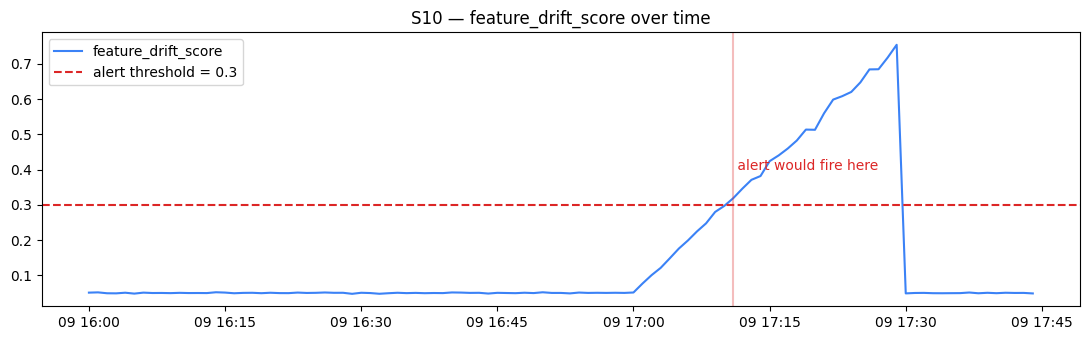

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

drift = pd.read_sql("""SELECT timestamp, value FROM metrics
                       WHERE scenario='S10' AND service='roc-installment-service'
                       AND metric='feature_drift_score'
                       ORDER BY timestamp""", conn)
drift['t'] = pd.to_datetime(drift['timestamp'])
print(f'{len(drift)} samples, baseline mean={drift.value[:60].mean():.3f}, peak={drift.value.max():.3f}')

# When does it actually cross alert threshold (0.30)?
threshold = 0.30
crossing = drift[drift['value'] > threshold].iloc[0] if (drift['value'] > threshold).any() else None
print(f'First crossing of {threshold}: {crossing["t"] if crossing is not None else "never"}')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(drift['t'], drift['value'], color='#3b82f6', label='feature_drift_score')
ax.axhline(threshold, color='#dc2626', linestyle='--', label=f'alert threshold = {threshold}')
if crossing is not None:
    ax.axvline(crossing['t'], color='#dc2626', alpha=0.3)
    ax.text(crossing['t'], 0.4, ' alert would fire here', color='#dc2626')
ax.set_title('S10 — feature_drift_score over time'); ax.legend(); plt.tight_layout(); plt.show()


## 8. Rolling z-score detector

Idea: use the first **60 samples** as baseline (the model is healthy on weekday traffic). Compute `mu`, `sigma`. For each later sample, compute `z = (value - mu) / sigma`. First sample where `z > 3` is your early-detection trigger.


Baseline: mu=0.0501, sigma=0.0009 (over first 60 samples)
Detector fires at: 2026-06-09 17:01:00+00:00
Lead time before alert would fire: 10 minutes


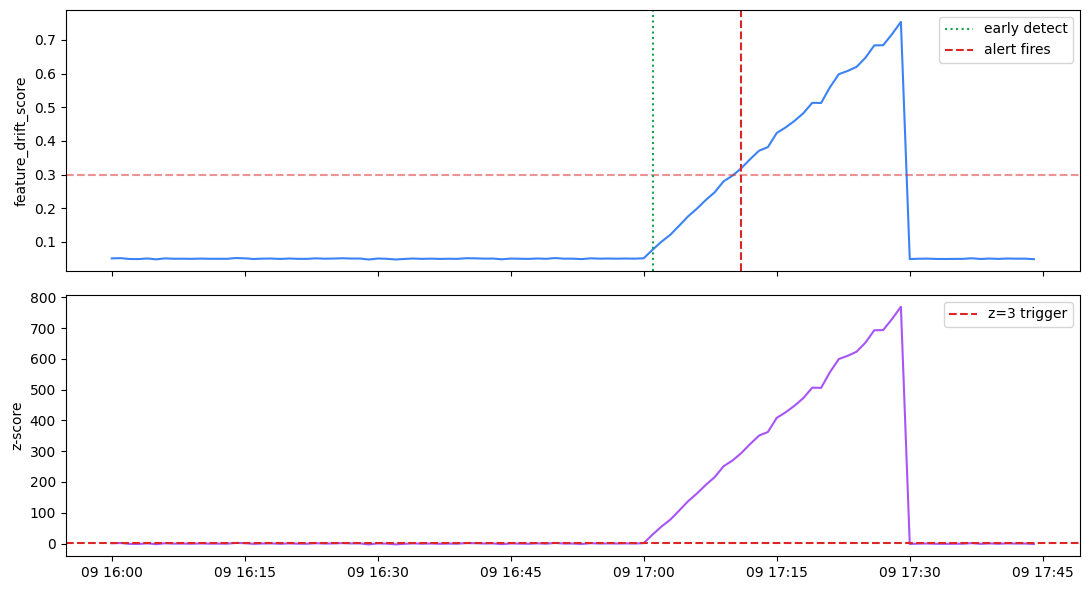

In [10]:
baseline_n = 60
mu = drift['value'].iloc[:baseline_n].mean()
sigma = max(drift['value'].iloc[:baseline_n].std(), 1e-6)
print(f'Baseline: mu={mu:.4f}, sigma={sigma:.4f} (over first {baseline_n} samples)')

drift['z'] = (drift['value'] - mu) / sigma
trigger_idx = drift[(drift['z'] > 3) & (drift.index >= baseline_n)].index
detect_at = drift.loc[trigger_idx[0], 't'] if len(trigger_idx) else None
print(f'Detector fires at: {detect_at}')

if crossing is not None and detect_at is not None:
    lead_min = (crossing['t'] - detect_at).total_seconds() / 60
    print(f'Lead time before alert would fire: {lead_min:.0f} minutes')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(drift['t'], drift['value'], color='#3b82f6')
axes[0].axhline(threshold, color='#dc2626', linestyle='--', alpha=0.5)
if detect_at is not None:
    axes[0].axvline(detect_at, color='#16a34a', linestyle=':', label='early detect')
if crossing is not None:
    axes[0].axvline(crossing['t'], color='#dc2626', linestyle='--', label='alert fires')
axes[0].set_ylabel('feature_drift_score'); axes[0].legend()
axes[1].plot(drift['t'], drift['z'], color='#a855f7')
axes[1].axhline(3, color='#dc2626', linestyle='--', label='z=3 trigger')
axes[1].set_ylabel('z-score'); axes[1].legend()
plt.tight_layout(); plt.show()


## 9. Your turn — tune the detector

Two EXERCISE challenges:

1. **Shrink the baseline window** to 30 samples. Does the detector fire **earlier** or **later**? Why?
2. **Use a tighter threshold** (`z > 2` instead of `z > 3`). What's the trade-off you observe?

Production AIOps tunes these knobs per metric per service. Cheaper detectors = earlier detection but more false positives. The tuning is empirical.


Baseline: mu=0.0501, sigma=0.0010 (over first 30 samples)
Detector fires at: 2026-06-09 17:01:00+00:00
Lead time before alert would fire: 10 minutes


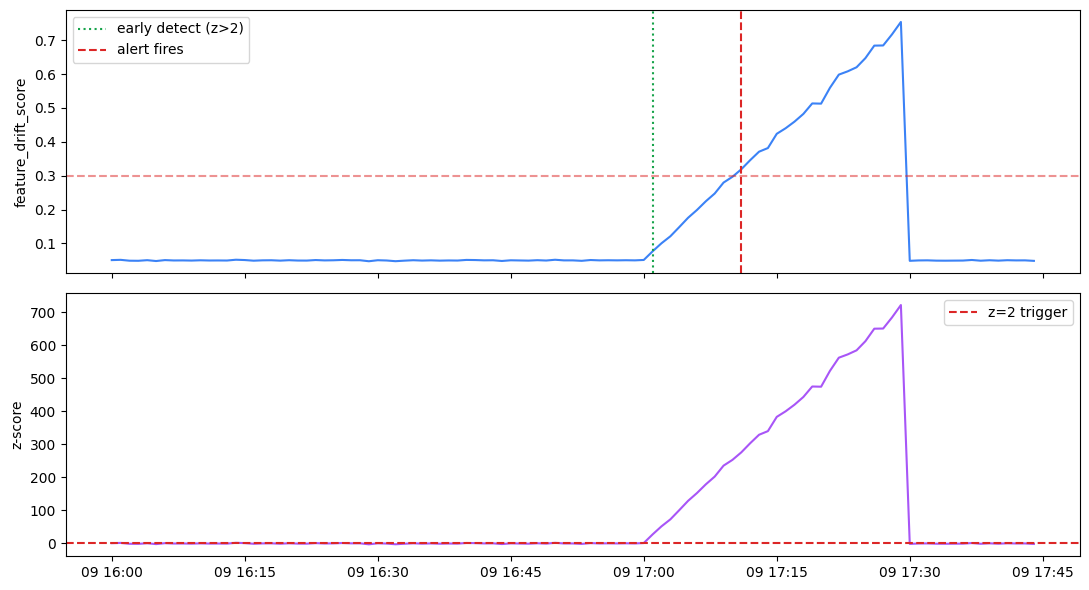

In [11]:
# EXERCISE 1 — baseline_n = 30. Report new detect_at + lead_time.
# EXERCISE 2 — z_threshold = 2. Report new detect_at + lead_time.
#
# Hint: copy the logic from cell 25, just change the two parameters.

baseline_n = 30
z_threshold = 2
mu = drift['value'].iloc[:baseline_n].mean()
sigma = max(drift['value'].iloc[:baseline_n].std(), 1e-6)
print(f'Baseline: mu={mu:.4f}, sigma={sigma:.4f} (over first {baseline_n} samples)')

drift['z2'] = (drift['value'] - mu) / sigma
trigger_idx2 = drift[(drift['z2'] > z_threshold) & (drift.index >= baseline_n)].index
s10_detect_at = drift.loc[trigger_idx2[0], 't'] if len(trigger_idx2) else None
print(f'Detector fires at: {s10_detect_at}')

if crossing is not None and s10_detect_at is not None:
    lead_min = (crossing['t'] - s10_detect_at).total_seconds() / 60
    print(f'Lead time before alert would fire: {lead_min:.0f} minutes')
else:
    print('No early detection found with these settings.')

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(drift['t'], drift['value'], color='#3b82f6')
axes[0].axhline(threshold, color='#dc2626', linestyle='--', alpha=0.5)
if s10_detect_at is not None:
    axes[0].axvline(s10_detect_at, color='#16a34a', linestyle=':', label=f'early detect (z>{z_threshold})')
if crossing is not None:
    axes[0].axvline(crossing['t'], color='#dc2626', linestyle='--', label='alert fires')
axes[0].set_ylabel('feature_drift_score')
axes[0].legend()
axes[1].plot(drift['t'], drift['z2'], color='#a855f7')
axes[1].axhline(z_threshold, color='#dc2626', linestyle='--', label=f'z={z_threshold} trigger')
axes[1].set_ylabel('z-score')
axes[1].legend()
plt.tight_layout(); plt.show()



### Discussion — auto-act on forecast?

The detector says drift starts ~X minutes before alert would fire. **Should you auto-remediate on that signal?**
 Không nên auto-remediate chỉ dựa trên forecast drift này.

Vì sao không?

Forecast là tín hiệu dự đoán, chưa chắc đã là incident thật.
Drift có thể tự phục hồi hoặc chỉ là biến động tạm thời.
Auto-remediate có thể gây hành động không cần thiết, tốn kém, thậm chí làm xấu hơn hệ thống.
Khi nào có thể cân nhắc auto?

Khi confidence rất cao.
Khi remediation thật sự cheap & reversible.
Ví dụ: cache-warm, tăng buffer nhẹ, không phải reboot/pod-restart hoặc rollback lớn.
Production best practice

Forecast thường nên dẫn tới “page human” trước.
Chỉ auto khi trust gate: đủ tín hiệu + remediation an toàn.
Đây đúng là cùng triết lý với cell 11: chỉ auto khi confidence lớn và action safe.


## 7. Discussion + wrap-up

1. **S08 confidence**: did RCA confidently identify the network policy as root? If yes — auto-remediate. If no — what additional signal would have raised confidence? (Hint: correlate with k8s audit log of recent `kubectl apply`.)
2. **S10 challenge**: alert-driven decision logic fails when there are no alerts. What's the alternative decision input? (Hint: model confidence on the FORECAST itself.)
3. **Verify step**: after auto-remediate, how would you verify recovery? Implement a simple check: "does latency p99 return below threshold within 5 min?" If not, **escalate**.
4. **Production reality**: most companies require human-in-loop for the first 6 months of auto-remediation. They log decisions, compare with what human would have done, build trust. Discuss why.


S08 confidence

Nếu RCA top service là k8s_networkpolicy với confidence >= 0.4 và action là rollback_last_applied_networkpolicy, thì đúng là có thể auto-remediate.
Nếu confidence thấp thì cần thêm tín hiệu: ví dụ audit log kubectl apply gần đây, để xác nhận có thay đổi network-policy đúng lúc incident xảy ra.

S10 challenge

Với S10 không có alert, decision logic dựa vào alert sẽ thất bại.
Thay vào đó cần dùng tín hiệu từ forecast/drift và model confidence trên cái forecast đó.
Ví dụ: feature_drift_score, model_inference_ms, và confidence của forecast event → page human nếu chưa đủ tin cậy.

Verify step

Sau auto-remediate phải kiểm tra recovery.
Ví dụ: xem latency p99 có trở về dưới ngưỡng trong 5 phút hay không.
Nếu không trở về baseline thì nên escalate / chuyển qua phê duyệt người thật.

Production reality

Thường cần human-in-loop ban đầu để xây trust.
Ghi lại quyết định auto và so sánh với quyết định human để học dần.
Mục tiêu: tránh false positive gây tác động không mong muốn, đặc biệt với remediation không dễ đảo ngược